# 指数加权平均

- 指数加权平均（Exponentially Weighted Average, EWA），在时间序列分析中也常被称为指数移动平均（EMA）。
- 它的核心思想是：
  - <font color='red'>越近期的数据权重越大，越久远的数据权重呈指数级衰减</font>
  
- 在深度学习中，它**被广泛用于**<font color='red'>优化器（如 Adam 中的动量估计）</font>和<font color='red'>评估指标（如训练 Loss 的平滑曲线）</font>。

下面为你提供从基础到进阶的 3 种 Python 实现方式：

## 基础实现：使用 for 循环（最直观）
这是最符合数学定义的实现方式，适合理解底层逻辑。

In [ ]:
def ewa_loop(data,beta=0.9):
    """
    beta（衰减系数）:通常在0.9到0.999之间
    - beta越大，历史数据的权重越大，曲线越平滑
    """
    result = []
    average = 0.0
    
    for v in data:
        # 核心递推公式：
        average = beta * average + (1 - beta) * v
        result.append(average)
    return result

## 进阶实现：使用 Pandas（<font color='red'>最常用</font>）
**在实际的数据科学和工程开发中，强烈推荐使用 Pandas，它的底层是用 C/C++ 优化的，速度极快且支持处理缺失值**。

In [ ]:
import pandas as pd
import numpy as np

data = np.random.randn(100)
series = pd.Series(data)

# 使用span参数（更直观）： span代表”半衰期“窗口大小，beta会自动计算
# 公式： beta = 1- 2/(span + 1)

smoothed = series.ewm(span=20,adjust=False).mean()

# 捉着直接指定beta
smoothed = series.ewm(alpha=0.1,adjust=False).mean()


## PyTorch 实现：张量批量计算
既然你之前在看 PyTorch，这里提供一个纯 PyTorch 的实现，适合在模型训练或 GPU 计算中使用。

In [ ]:
import torch

def ewa_torch(data_tensor,beta=0.9):
    """
    data_tensor:一维张量
    """
    result = torch.zeros_like(data_tensor,dtype=torch.float32)
    average = torch.tensor(0.0)
    for i,v in enumerate(data_tensor):
        average = beta * average + (1 - beta) * v
        result[i] = average
    return result

## 核心避坑指南：冷启动偏差（Bias Correction）
- 使用 EWA 时有一个极其经典的坑：**初始偏差**。
  - <font color='red'>因为我们在计算时通常将初始值设为 0，这意味着在序列刚开始的前几个点，平均值会被 0 严重拉低。</font>
  
### 解决方案：偏差修正（Bias Correction）
  - 在 Adam 优化器中，这个技术被广泛使用。公式为：
$\hat{v_t} = \frac{v_t}{1 - β^t}$

### 代码演示：

In [ ]:
def ewa_with_correction(data,beta=0.9):
    result = []
    average = 0.0
    
    for i ,v in enumerate(data,start=1): # i从1开始
        average = beta * average + (1 - beta) * v
        
        # 偏差修正： 除以(1 - beta^i)
        corrected_average = average / (1 - beta ** i)
        result.append(corrected_average)
    return result

### 直观对比：
如果 data = [10, 10, 10, 10]，beta = 0.9：
- 未修正：[1.0, 2.8, 4.52, 6.068] （**起步极低，慢慢爬升**）
- 已修正：[10.0, 10.0, 10.0, 10.0] （完美修正了冷启动的偏差）

|      | 无修正      | 有修正     |
| :--- | :------- | :------ |
| 初期行为 | 缓慢从 0 爬升 | 快速响应真实值 |
| 适用场景 | 指标平滑显示   | 优化器动量估计 |

### β 参数的选择

| $\beta$ |  有效窗口  | 平滑程度 | 适用场景                 |
| :-----: | :----: | :--: | :------------------- |
|   0.5   |   2 步  |  很轻  | 快速变化的指标              |
|   0.9   |  10 步  |  中等  | **Reward 曲线平滑、训练日志** |
|   0.99  |  100 步 |   强  | 模型参数 EMA             |
|  0.999  | 1000 步 |  极强  | 大模型训练中的模型平均          |


### 有效窗口
- 是 EMA 中一个近似概念：<font color='red'>它回答了"当前平滑值 $s_t$主要受过去多少步的数据影响"</font>

权重随时间呈指数衰减。我们问：衰减到什么比例时，认为"不再有效"？



In [2]:
from IPython.display import Image


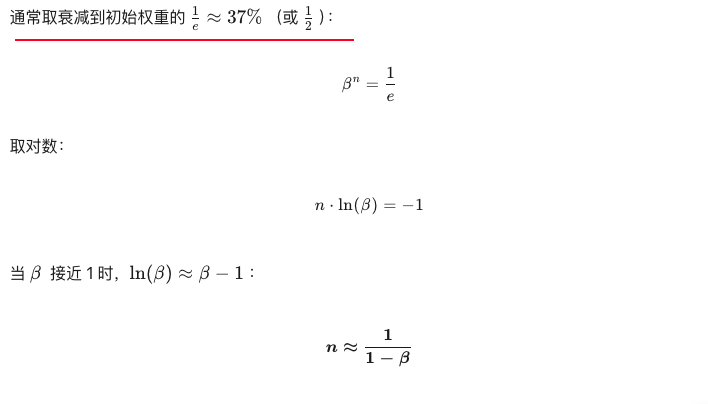

In [4]:
Image(filename='./Image/ewa.png')

#### 直观对照表
|  β  | 有效窗口 n ≈ 1/(1-β ) | 含义              |
| :-------: | :--------------------------------: | :-------------- |
|  **0.5**  |           $1/(0.5) = 2$ 步          | 只记最近 2 步，"金鱼记忆" |
|  **0.9**  |          $1/(0.1) = 10$ 步          | 约最近 10 步的加权平均   |
|  **0.99** |         $1/(0.01) = 100$ 步         | 约最近 100 步的加权平均  |
| **0.999** |        $1/(0.001) = 1000$ 步        | 约最近 1000 步的加权平均 |

#### 直观类比
想象你在听一首有背景噪音的歌：

| $\beta$   | 类比            | 效果                        |
| :-------- | :------------ | :------------------------ |
| **0.5**   | 只记住最近 2 个音符   | 噪音几乎没过滤，音乐断断续续            |
| **0.9**   | 记住最近 10 个音符   | **最佳平衡点**，旋律清晰，反应及时       |
| **0.99**  | 记住最近 100 个音符  | 旋律非常平滑，但新节奏出现 100 步后才反应过来 |
| **0.999** | 记住最近 1000 个音符 | 像"百年老唱片机"，几乎不响应变化         |
#### 代码验证

In [1]:
import numpy as np

def effective_window(beta, threshold=1/np.e):
    """计算权重衰减到 threshold 所需的步数"""
    return np.log(threshold) / np.log(beta)

for beta in [0.5, 0.9, 0.99, 0.999]:
    n = effective_window(beta)
    approx = 1 / (1 - beta)
    print(f"β={beta}: 精确窗口={n:.1f}步, 近似 1/(1-β)={approx:.1f}步")

β=0.5: 精确窗口=1.4步, 近似 1/(1-β)=2.0步
β=0.9: 精确窗口=9.5步, 近似 1/(1-β)=10.0步
β=0.99: 精确窗口=99.5步, 近似 1/(1-β)=100.0步
β=0.999: 精确窗口=999.5步, 近似 1/(1-β)=1000.0步
